# Modeling - Homophily

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

from data_prep import load_run_data, build_global_init_map, build_run_trajectory, build_neighbors_index, _numeric_agent_key
from baseline_utils import (
    fit_degroot_adjacency_scalar,
    degroot_rollout_prediction,
    evaluate_validation_model,
    fit_friedkin_johnsen_adjacency,
    select_friedkin_johnsen_adjacency_lambdas,
    friedkin_johnsen_adjacency_rollout,
    align_rollout_pair,
)
from opinion_fitting import fit_homophily, rollout_with_homophily, fit_homophily_stubborness, rollout_with_homophily_stubborness
from plot_utils import (
    plot_mean_per_timestep,
    plot_variance_per_timestep,
    plot_wasserstein_distance_per_timestep,
    plot_observed_trajectories,
    plot_predicted_vs_observed,
    plot_box_per_timestep,
    plot_violin_per_timestep,
    compute_mean_prediction_error,
    compute_max_prediction_error,
)

ROOT = Path('..').resolve()
CLEAN = ROOT / 'cleaned_data'

PARAMS = {
    'target_agent_fraction': 0.4,
    'constrain_messages': 150,
    'rollout_horizon_cap': 20,
    'validation_horizon': 8,
}

RUN_DIRS = sorted([p for p in CLEAN.iterdir() if p.is_dir()])
print('Project root:', ROOT)
print('Cleaned data:', CLEAN)
print('Runs found:', len(RUN_DIRS))
for r in RUN_DIRS[:26]:
    print(' ', r.name)

Project root: /Users/samuelli/Documents/code/llm/llm-network/modeling
Cleaned data: /Users/samuelli/Documents/code/llm/llm-network/modeling/cleaned_data
Runs found: 67
  run_20260320-130058
  run_20260320-133304
  run_20260320-140500
  run_20260320-143643
  run_20260320-150827
  run_20260320-154019
  run_20260320-161210
  run_20260320-164400
  run_20260320-171544
  run_20260320-174722
  run_20260321-121900
  run_20260321-125108
  run_20260321-132251
  run_20260321-135440
  run_20260321-142622
  run_20260321-145803
  run_20260321-152938
  run_20260321-160106
  run_20260321-163235
  run_20260321-170416
  run_20260322-212540
  run_20260324-095805
  run_20260324-115915
  run_20260324-135956
  run_20260324-160041
  run_20260326-014533


## Data Construction

- Each run is mapped to a shared global agent index.
- Trajectories are built from the run data with the same preprocessing used in the baseline notebook.
- Neighbor sets are preserved per run for the homophily kernel.

In [2]:
RUN_DATA = {r.name: load_run_data(r) for r in RUN_DIRS}
GLOBAL_AGENT_IDS = sorted({a for d in RUN_DATA.values() for a in d['agent_ids']}, key=_numeric_agent_key)
N = len(GLOBAL_AGENT_IDS)

GLOBAL_INIT_BY_AGENT = build_global_init_map(RUN_DATA, GLOBAL_AGENT_IDS)
RUN_TRAJ_AND_MASK = {
    rn: build_run_trajectory(
        d,
        GLOBAL_AGENT_IDS,
        target_agent_fraction=PARAMS['target_agent_fraction'],
        return_post_mask=True,
        constrain_messages=PARAMS['constrain_messages'],
    )
    for rn, d in RUN_DATA.items()
}
RUN_TRAJ = {rn: tm[0] for rn, tm in RUN_TRAJ_AND_MASK.items()}
RUN_POST_MASK = {rn: tm[1] for rn, tm in RUN_TRAJ_AND_MASK.items()}
RUN_NEIGHBORS = {rn: build_neighbors_index(d, GLOBAL_AGENT_IDS) for rn, d in RUN_DATA.items()}

print('Global agent count:', N)
print('Global init priors available:', len(GLOBAL_INIT_BY_AGENT))
for rn in sorted(RUN_TRAJ.keys()):
    tr = RUN_TRAJ[rn]
    print(f'{rn}: trajectory shape={tr.shape}, horizon={tr.shape[0] - 1}')

Global agent count: 30
Global init priors available: 30
run_20260320-130058: trajectory shape=(9, 30), horizon=8
run_20260320-133304: trajectory shape=(12, 30), horizon=11
run_20260320-140500: trajectory shape=(9, 30), horizon=8
run_20260320-143643: trajectory shape=(9, 30), horizon=8
run_20260320-150827: trajectory shape=(9, 30), horizon=8
run_20260320-154019: trajectory shape=(11, 30), horizon=10
run_20260320-161210: trajectory shape=(9, 30), horizon=8
run_20260320-164400: trajectory shape=(11, 30), horizon=10
run_20260320-171544: trajectory shape=(9, 30), horizon=8
run_20260320-174722: trajectory shape=(10, 30), horizon=9
run_20260321-121900: trajectory shape=(11, 30), horizon=10
run_20260321-125108: trajectory shape=(10, 30), horizon=9
run_20260321-132251: trajectory shape=(8, 30), horizon=7
run_20260321-135440: trajectory shape=(12, 30), horizon=11
run_20260321-142622: trajectory shape=(10, 30), horizon=9
run_20260321-145803: trajectory shape=(10, 30), horizon=9
run_20260321-15293

In [3]:
print('RUN_TRAJ post-rate audit (posts / N per time slice, from RUN_POST_MASK)')
print('N =', N)
all_post_fracs = []
for rn in sorted(RUN_TRAJ.keys()):
    tr = np.asarray(RUN_TRAJ[rn], dtype=float)
    pm = np.asarray(RUN_POST_MASK[rn], dtype=bool)
    per_slice_post_frac = pm.mean(axis=1)
    all_post_fracs.extend(per_slice_post_frac.tolist())
    print(f"{rn}: post_mean={np.mean(per_slice_post_frac):.3f}, post_min={np.min(per_slice_post_frac):.3f}, post_max={np.max(per_slice_post_frac):.3f}, slices={tr.shape[0]}")

if all_post_fracs:
    print('\nGlobal RUN_TRAJ post-rate summary:')
    print(f"mean={np.mean(all_post_fracs):.3f}, median={np.median(all_post_fracs):.3f}, min={np.min(all_post_fracs):.3f}, max={np.max(all_post_fracs):.3f}, total_slices={len(all_post_fracs)}")

RUN_TRAJ post-rate audit (posts / N per time slice, from RUN_POST_MASK)
N = 30
run_20260320-130058: post_mean=0.256, post_min=0.100, post_max=0.367, slices=9
run_20260320-133304: post_mean=0.244, post_min=0.167, post_max=0.367, slices=12
run_20260320-140500: post_mean=0.341, post_min=0.233, post_max=0.433, slices=9
run_20260320-143643: post_mean=0.267, post_min=0.100, post_max=0.367, slices=9
run_20260320-150827: post_mean=0.289, post_min=0.233, post_max=0.367, slices=9
run_20260320-154019: post_mean=0.267, post_min=0.100, post_max=0.400, slices=11
run_20260320-161210: post_mean=0.278, post_min=0.133, post_max=0.367, slices=9
run_20260320-164400: post_mean=0.255, post_min=0.067, post_max=0.433, slices=11
run_20260320-171544: post_mean=0.326, post_min=0.233, post_max=0.400, slices=9
run_20260320-174722: post_mean=0.253, post_min=0.133, post_max=0.367, slices=10
run_20260321-121900: post_mean=0.248, post_min=0.200, post_max=0.333, slices=11
run_20260321-125108: post_mean=0.290, post_min=

## Homophily

In [4]:
HOMOPHILY = fit_homophily(RUN_TRAJ, RUN_NEIGHBORS, gamma0=1.0)
HOMOPHILY_A = HOMOPHILY['Abar']
HOMOPHILY_GAMMA = HOMOPHILY['gamma']

print('Homophily fit')
print('gamma:', HOMOPHILY_GAMMA)
print('Global pooled MSE loss:', HOMOPHILY['mse_pool'])

Homophily fit
gamma: 12.07499793826636
Global pooled MSE loss: 0.01589624770878232


In [5]:
BEST_HOMO_STUB = fit_homophily_stubborness(
    RUN_TRAJ,
    RUN_NEIGHBORS,
    gamma0=HOMOPHILY_GAMMA,
    lambda1=0.0,
    lambda2=0.0,
    bias0=0.0,
)

homo_stub_rows = [{
    "lambda1": BEST_HOMO_STUB["lambda1"],
    "lambda2": BEST_HOMO_STUB["lambda2"],
    "gamma": BEST_HOMO_STUB["gamma"],
    "bias": BEST_HOMO_STUB["bias"],
    "mse_pool": BEST_HOMO_STUB["mse_pool"],
    "success": BEST_HOMO_STUB["success"],
    "nit": BEST_HOMO_STUB["nit"],
    "status": BEST_HOMO_STUB["status"],
}]

HOMO_STUB_LAMBDA_TABLE = pd.DataFrame(homo_stub_rows).sort_values("mse_pool").reset_index(drop=True)

print("Best homophily+stubbornness fit (inner lambda optimization + outer gamma search)")
print("lambda1:", BEST_HOMO_STUB["lambda1"])
print("lambda2:", BEST_HOMO_STUB["lambda2"])
print("gamma:", BEST_HOMO_STUB["gamma"])
print("bias:", BEST_HOMO_STUB["bias"])
print("mse_pool:", BEST_HOMO_STUB["mse_pool"])
print("gamma grid tested:", len(BEST_HOMO_STUB.get("gamma_grid", [])))

HOMO_STUB_A = BEST_HOMO_STUB["Abar"]
HOMO_STUB_GAMMA = BEST_HOMO_STUB["gamma"]
HOMO_STUB_BIAS = BEST_HOMO_STUB["bias"]
HOMO_STUB_L1 = BEST_HOMO_STUB["lambda1"]
HOMO_STUB_L2 = BEST_HOMO_STUB["lambda2"]

HOMO_STUB_LAMBDA_TABLE.head(10)

Best homophily+stubbornness fit (inner lambda optimization + outer gamma search)
lambda1: 0.07976302443813028
lambda2: 0.17999638615981553
gamma: 44.484672750591
bias: 0.4866358337952511
mse_pool: 0.014604899639478223
gamma grid tested: 111


,lambda1,lambda2,gamma,bias,mse_pool,success,nit,status
0,0.079763,0.179996,44.484673,0.486636,0.014605,True,50,optimal


DeGroot adjacency gamma: 0.29378838899890913
FJ adjacency lambdas: 0.0 0.19999999999999998
FJ adjacency gamma: 0.14513692406860046
FJ adjacency bias: 0.5049680670798372
Training metric horizon (shared): 5
Degroot


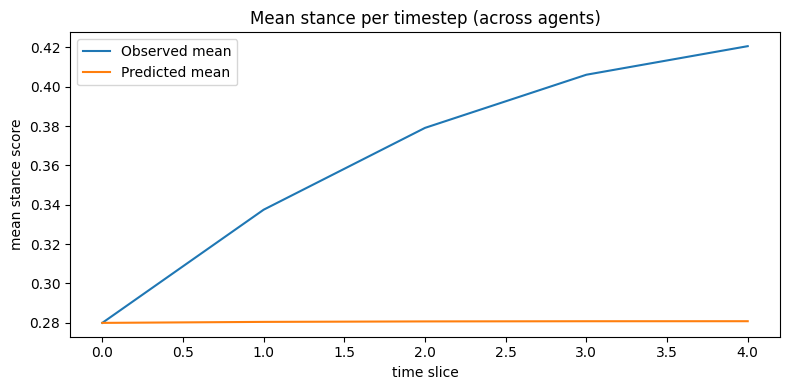

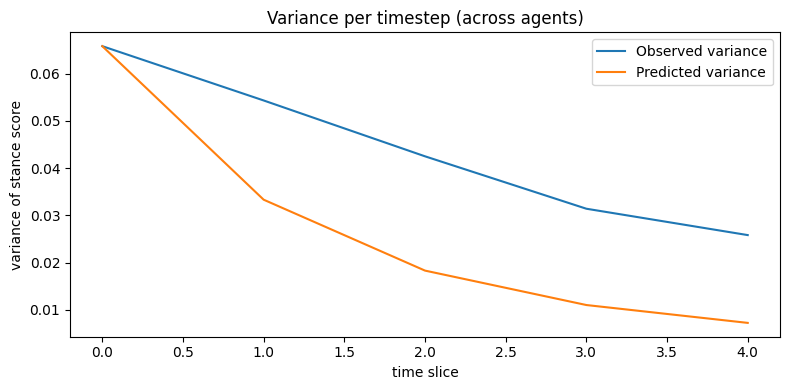

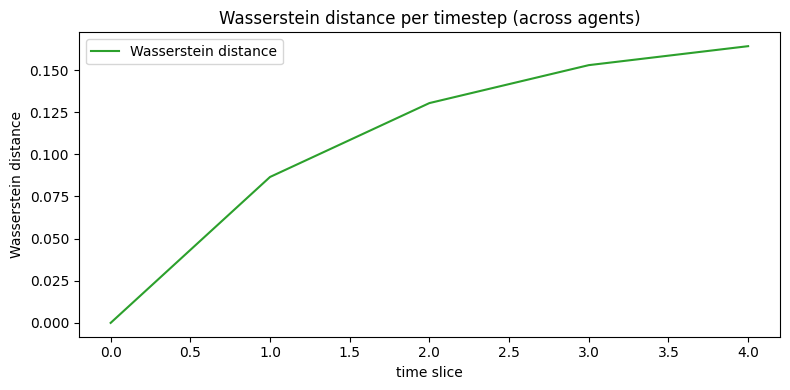

FJ adjacency


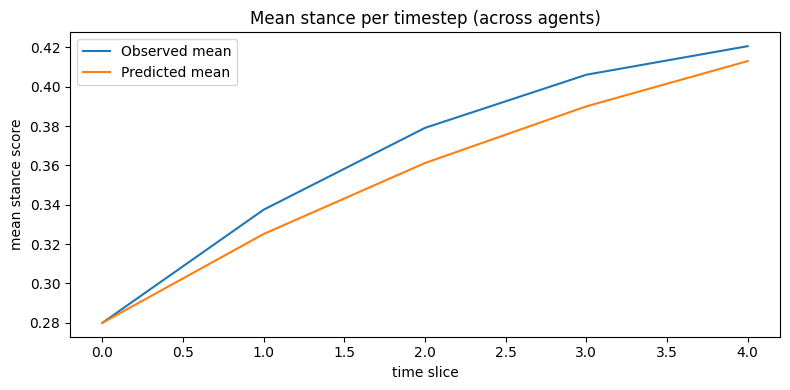

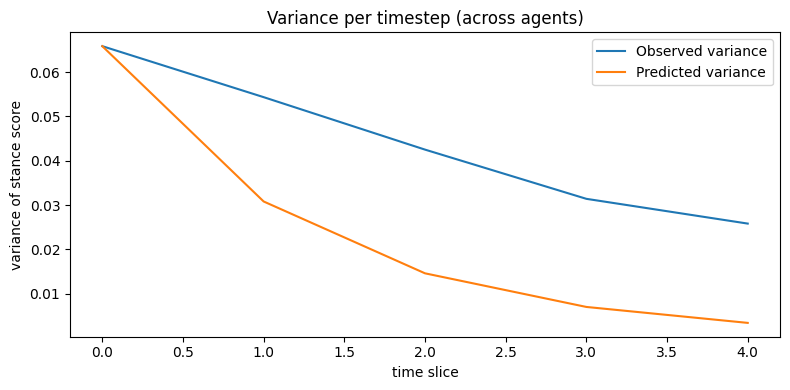

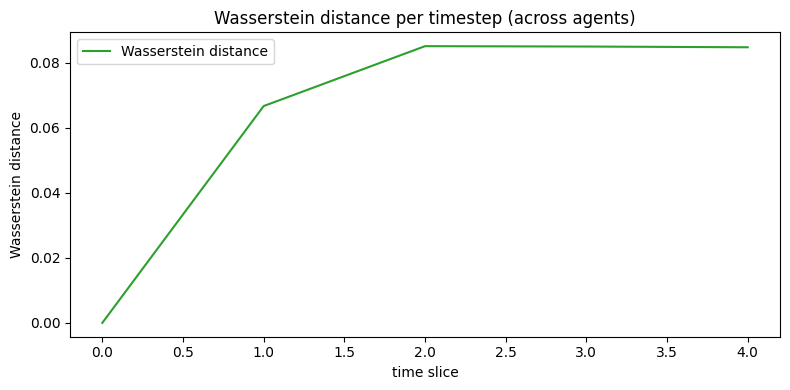

Homophily


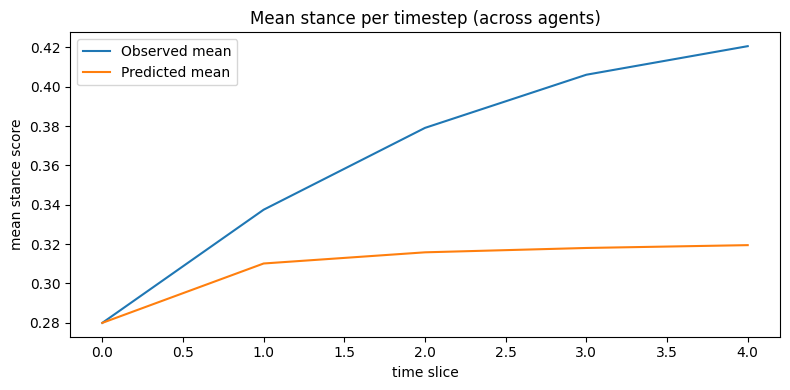

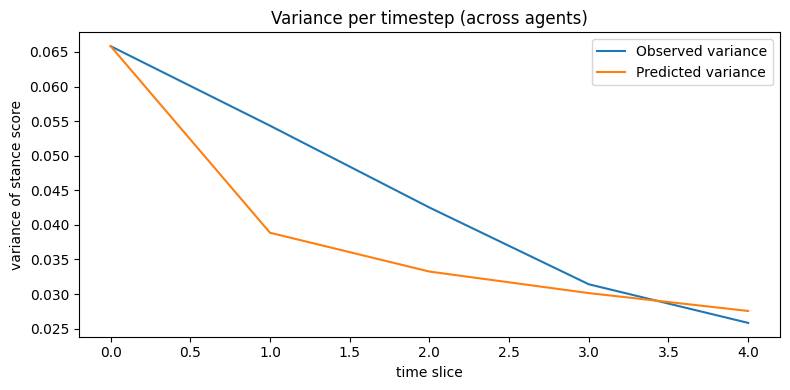

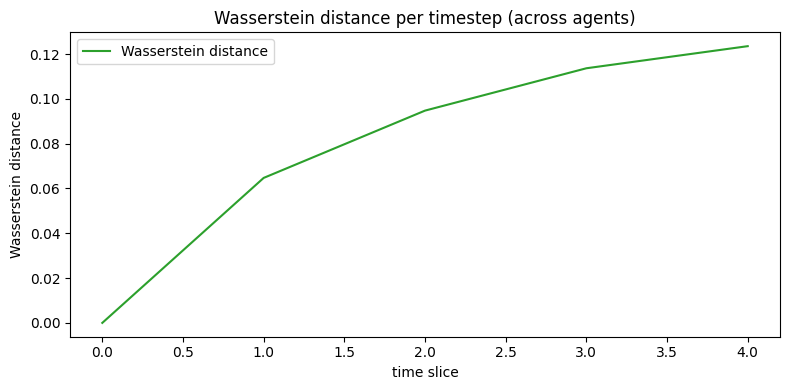

Homophily stubbornness


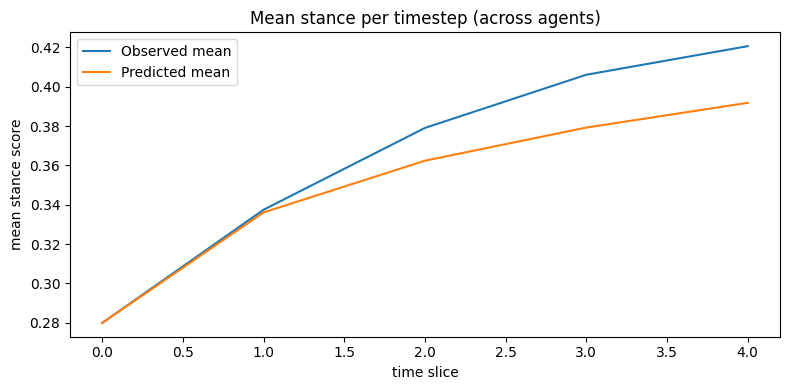

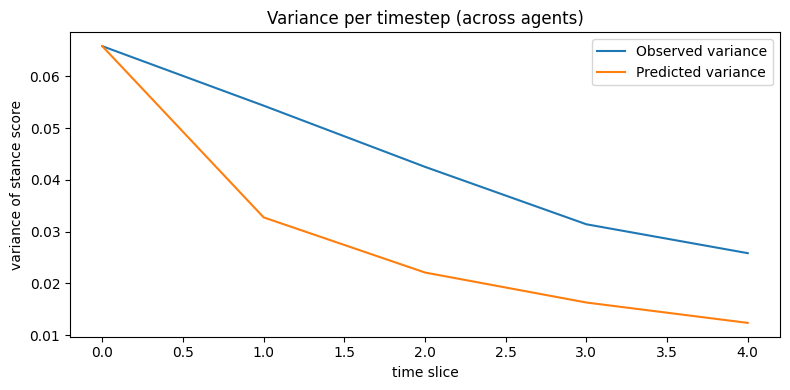

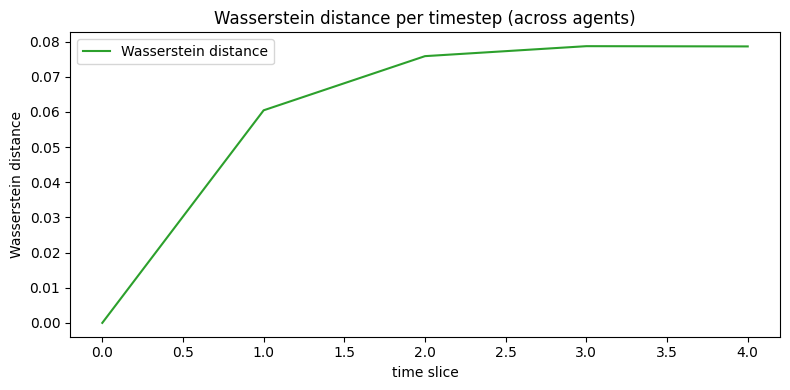

                      model  pooled_mse  transition_mse_mean  \
0  degroot_adjacency_scalar    0.012080             0.039759   
1              fj_adjacency    0.011225             0.018829   
2                 homophily    0.015896             0.045073   
3    homophily_stubbornness    0.014605             0.023505   

   mean_curve_abs_error  var_curve_abs_error  wasserstein_curve_mean  
0              0.084321             0.017300                0.106829  
1              0.030817             0.019929                0.064271  
2              0.061056             0.012238                0.079338  
3              0.032586             0.014846                0.058724  


In [6]:
degroot_adj = fit_degroot_adjacency_scalar(RUN_TRAJ, RUN_NEIGHBORS)
GLOBAL_W = degroot_adj['W']
DEGROOT_GAMMA = degroot_adj['gamma']
DEGROOT_POOL_MSE = degroot_adj['mse_pool']

# FJ adjacency model from baseline_utils: select lambdas by grid, then fit gamma+bias.
LAMBDA_GRID = np.linspace(0.0, 0.6, 13)
BEST_FJ_ADJ, FJ_ADJ_GRID = select_friedkin_johnsen_adjacency_lambdas(
    RUN_TRAJ,
    RUN_NEIGHBORS,
    LAMBDA_GRID,
 )
FJ_ADJ_L1 = BEST_FJ_ADJ['lambda1']
FJ_ADJ_L2 = BEST_FJ_ADJ['lambda2']
FJ_ADJ_FIT = fit_friedkin_johnsen_adjacency(
    RUN_TRAJ,
    RUN_NEIGHBORS,
    FJ_ADJ_L1,
    FJ_ADJ_L2,
)
FJ_ADJ_GAMMA = FJ_ADJ_FIT['gamma']
FJ_ADJ_BIAS = FJ_ADJ_FIT['bias']
FJ_ADJ_W = FJ_ADJ_FIT['W']
FJ_ADJ_POOL_MSE = FJ_ADJ_FIT['mse_pool']

PREDICTED_TRAJ_DEGROOT = {
    rn: degroot_rollout_prediction(
        GLOBAL_W,
        np.asarray(RUN_TRAJ[rn], dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    )
    for rn in RUN_TRAJ.keys()
}
PREDICTED_TRAJ_FJ_ADJ = {
    rn: friedkin_johnsen_adjacency_rollout(
        FJ_ADJ_W,
        FJ_ADJ_BIAS,
        np.asarray(RUN_TRAJ[rn], dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        FJ_ADJ_L1,
        FJ_ADJ_L2,
    )
    for rn in RUN_TRAJ.keys()
}
PREDICTED_TRAJ_HOMO = {
    rn: rollout_with_homophily(HOMOPHILY_A, HOMOPHILY_GAMMA, np.asarray(RUN_TRAJ[rn], dtype=float)[0], PARAMS['rollout_horizon_cap'])
    for rn in RUN_TRAJ.keys()
}

PREDICTED_TRAJ_HOMO_STUB = {
    rn: rollout_with_homophily_stubborness(
        HOMO_STUB_A,
        HOMO_STUB_GAMMA,
        HOMO_STUB_BIAS,
        HOMO_STUB_L1,
        HOMO_STUB_L2,
        np.asarray(RUN_TRAJ[rn], dtype=float)[0],
        PARAMS["rollout_horizon_cap"],
    )
    for rn in RUN_TRAJ.keys()
}

TRAIN_DEGROOT = evaluate_validation_model(
    RUN_TRAJ,
    lambda observed: degroot_rollout_prediction(
        GLOBAL_W,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    ),
)
TRAIN_FJ_ADJ = evaluate_validation_model(
    RUN_TRAJ,
    lambda observed: friedkin_johnsen_adjacency_rollout(
        FJ_ADJ_W,
        FJ_ADJ_BIAS,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        FJ_ADJ_L1,
        FJ_ADJ_L2,
    ),
)
TRAIN_HOMO = evaluate_validation_model(
    RUN_TRAJ,
    lambda observed: rollout_with_homophily(
        HOMOPHILY_A,
        HOMOPHILY_GAMMA,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    ),
)

TRAIN_HOMO_STUB = evaluate_validation_model(
    RUN_TRAJ,
    lambda observed: rollout_with_homophily_stubborness(
        HOMO_STUB_A,
        HOMO_STUB_GAMMA,
        HOMO_STUB_BIAS,
        HOMO_STUB_L1,
        HOMO_STUB_L2,
        np.asarray(observed, dtype=float)[0],
        PARAMS["rollout_horizon_cap"],
    ),
)

TRAIN_CURVE_HORIZON = min(
    TRAIN_DEGROOT['mean_true_stack'].shape[1],
    TRAIN_FJ_ADJ['mean_true_stack'].shape[1],
    TRAIN_HOMO['mean_true_stack'].shape[1],
    TRAIN_HOMO_STUB['mean_true_stack'].shape[1],
)
print('DeGroot adjacency gamma:', DEGROOT_GAMMA)
print('FJ adjacency lambdas:', FJ_ADJ_L1, FJ_ADJ_L2)
print('FJ adjacency gamma:', FJ_ADJ_GAMMA)
print('FJ adjacency bias:', FJ_ADJ_BIAS)
print('Training metric horizon (shared):', TRAIN_CURVE_HORIZON)

print('Degroot')
plot_mean_per_timestep(
    TRAIN_DEGROOT['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_DEGROOT['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_DEGROOT['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_DEGROOT['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_DEGROOT['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

print('FJ adjacency')
plot_mean_per_timestep(
    TRAIN_FJ_ADJ['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_FJ_ADJ['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_FJ_ADJ['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_FJ_ADJ['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_FJ_ADJ['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

print('Homophily')
plot_mean_per_timestep(
    TRAIN_HOMO['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_HOMO['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_HOMO['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

print('Homophily stubbornness')
plot_mean_per_timestep(
    TRAIN_HOMO_STUB['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO_STUB['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_HOMO_STUB['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO_STUB['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_HOMO_STUB['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

train_summary = pd.DataFrame([
    {
        'model': 'degroot_adjacency_scalar',
        'pooled_mse': DEGROOT_POOL_MSE,
        'transition_mse_mean': TRAIN_DEGROOT['transition_mse_mean'],
        'mean_curve_abs_error': TRAIN_DEGROOT['mean_curve_abs_error'],
        'var_curve_abs_error': TRAIN_DEGROOT['var_curve_abs_error'],
        'wasserstein_curve_mean': TRAIN_DEGROOT['wasserstein_curve_mean'],
    },
    {
        'model': 'fj_adjacency',
        'pooled_mse': FJ_ADJ_POOL_MSE,
        'transition_mse_mean': TRAIN_FJ_ADJ['transition_mse_mean'],
        'mean_curve_abs_error': TRAIN_FJ_ADJ['mean_curve_abs_error'],
        'var_curve_abs_error': TRAIN_FJ_ADJ['var_curve_abs_error'],
        'wasserstein_curve_mean': TRAIN_FJ_ADJ['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily',
        'pooled_mse': HOMOPHILY['mse_pool'],
        'transition_mse_mean': TRAIN_HOMO['transition_mse_mean'],
        'mean_curve_abs_error': TRAIN_HOMO['mean_curve_abs_error'],
        'var_curve_abs_error': TRAIN_HOMO['var_curve_abs_error'],
        'wasserstein_curve_mean': TRAIN_HOMO['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily_stubbornness',
        'pooled_mse': BEST_HOMO_STUB['mse_pool'],
        'transition_mse_mean': TRAIN_HOMO_STUB['transition_mse_mean'],
        'mean_curve_abs_error': TRAIN_HOMO_STUB['mean_curve_abs_error'],
        'var_curve_abs_error': TRAIN_HOMO_STUB['var_curve_abs_error'],
        'wasserstein_curve_mean': TRAIN_HOMO_STUB['wasserstein_curve_mean'],
    }
])
print(train_summary)

In [ ]:
# AIC/BIC ablation table on training set (degroot, stubbornness/FJ-adjacency, homophily, homophily-stubbornness).
def flatten_eval_result(eval_result):
    obs_curves = []
    pred_curves = []
    for rn in sorted(eval_result['per_run'].keys()):
        observed = np.asarray(eval_result['per_run'][rn]['observed'], dtype=float)
        predicted = np.asarray(eval_result['per_run'][rn]['predicted'], dtype=float)
        observed, predicted = align_rollout_pair(observed, predicted)
        obs_curves.append(observed.ravel())
        pred_curves.append(predicted.ravel())
    return np.concatenate(obs_curves), np.concatenate(pred_curves)

train_eval_map = {
    'degroot': (TRAIN_DEGROOT, 1),
    'stubbornness': (TRAIN_FJ_ADJ, 4),
    'homophily': (TRAIN_HOMO, 1),
    'homophily_stubbornness': (TRAIN_HOMO_STUB, 4),
}

train_ablation_rows = []
for model_name, (eval_result, num_params) in train_eval_map.items():
    y_true_flat, y_pred_flat = flatten_eval_result(eval_result)
    mean_stats = compute_mean_prediction_error(y_true_flat, y_pred_flat, num_params=num_params)
    max_stats = compute_max_prediction_error(y_true_flat, y_pred_flat, num_params=num_params)
    train_ablation_rows.append({
        'model': model_name,
        'num_params': num_params,
        'mean_abs_error': mean_stats['mean_error'],
        'max_abs_error': max_stats['max_error'],
        'mse_aic': mean_stats['aic'],
        'mse_bic': mean_stats['bic'],
        'mae_aic': max_stats['aic'],
        'mae_bic': max_stats['bic'],
    })

train_ablation_aic_bic = pd.DataFrame(train_ablation_rows).sort_values('mse_aic').reset_index(drop=True)
print(train_ablation_aic_bic)

                       model  num_params  mean_abs_error  max_abs_error  \
0  stubbornness_fj_adjacency           4        0.091788       0.886781   
1     homophily_stubbornness           4        0.104863       0.890525   
2                    degroot           1        0.161345       0.812915   
3                  homophily           1        0.142281       1.040422   

        mse_aic       mse_bic      mae_aic      mae_bic  
0 -73495.045637 -73463.721970 -4461.848305 -4430.524637  
1 -69137.416602 -69106.092934 -4305.120753 -4273.797085  
2 -58988.085706 -58980.254789 -7703.180207 -7695.349290  
3 -56403.111040 -56395.280123  1476.111829  1483.942746  


## Validation

In [8]:
TEST_DATA_ROOT = ROOT / 'init_conditions'
TEST_RUN_DIRS = sorted([p for p in TEST_DATA_ROOT.iterdir() if p.is_dir()])
TEST_RUN_DATA = {r.name: load_run_data(r) for r in TEST_RUN_DIRS}
TEST_RUN_TRAJ_AND_MASK = {
    rn: build_run_trajectory(
        data,
        GLOBAL_AGENT_IDS,
        target_agent_fraction=PARAMS['target_agent_fraction'],
        return_post_mask=True,
        constrain_messages=PARAMS['constrain_messages'],
    )
    for rn, data in TEST_RUN_DATA.items()
}
TEST_RUN_TRAJ = {rn: tm[0] for rn, tm in TEST_RUN_TRAJ_AND_MASK.items()}
TEST_RUN_NEIGHBORS = {rn: build_neighbors_index(data, GLOBAL_AGENT_IDS) for rn, data in TEST_RUN_DATA.items()}
TEST_RUN_NAMES = sorted(TEST_RUN_TRAJ.keys())
print('Validation runs found:', len(TEST_RUN_NAMES))

Validation runs found: 8


Validation metric horizon (shared): 5
Degroot


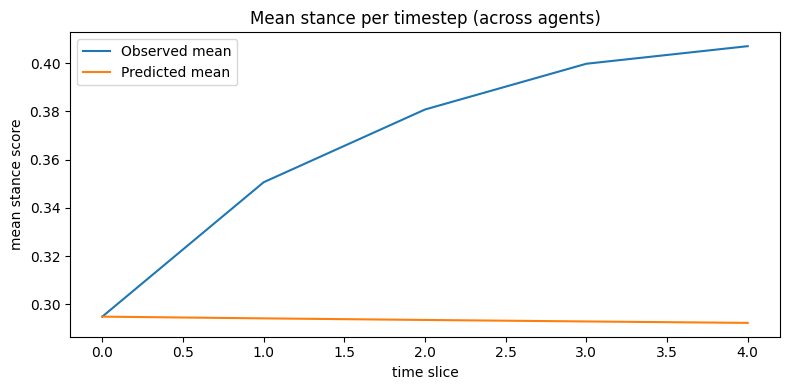

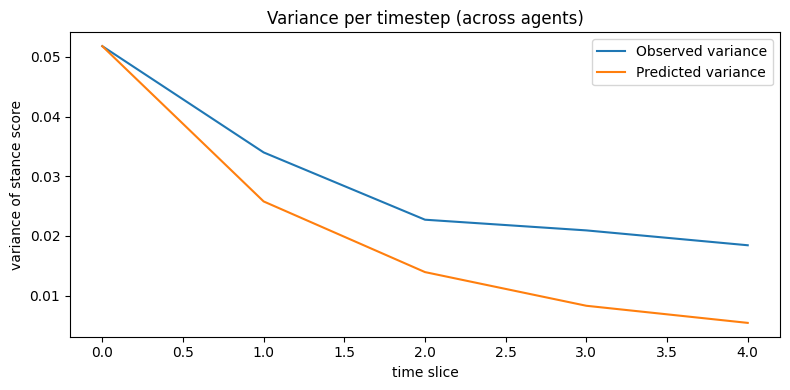

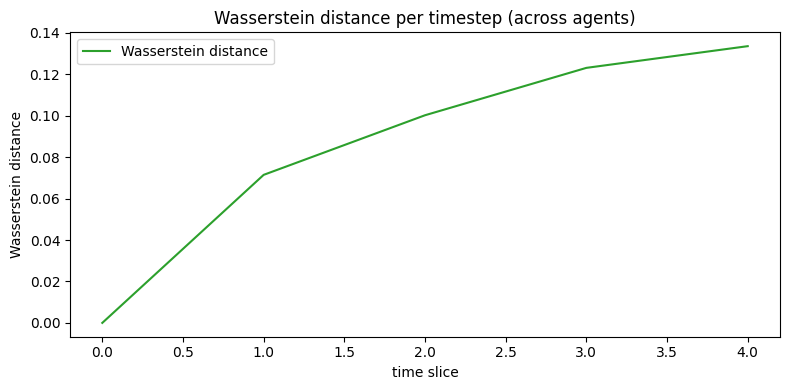

FJ adjacency


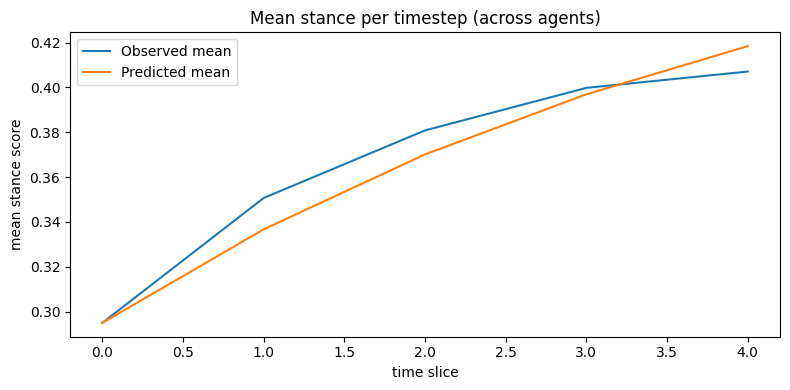

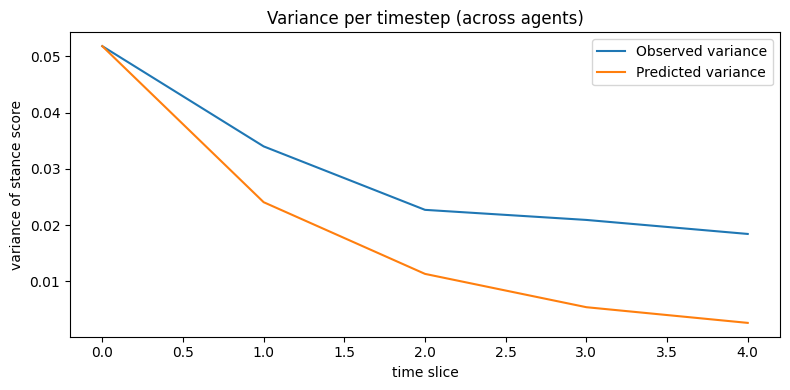

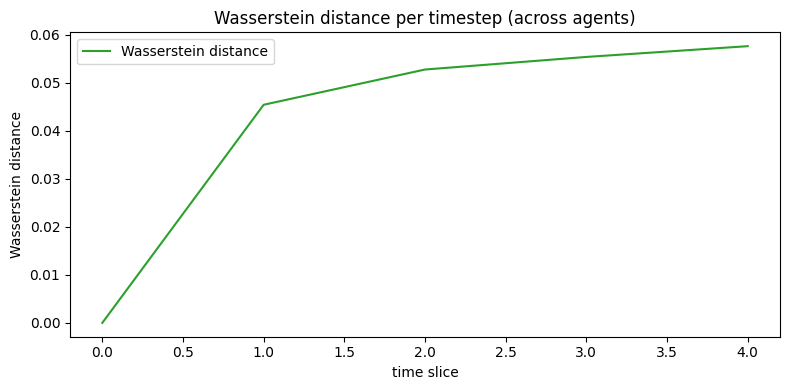

Homophily


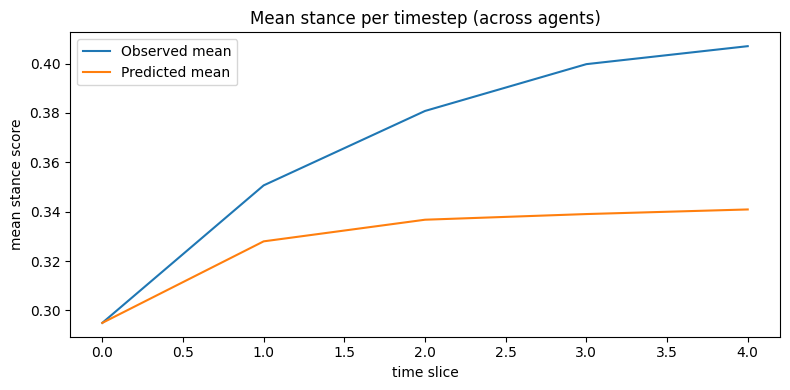

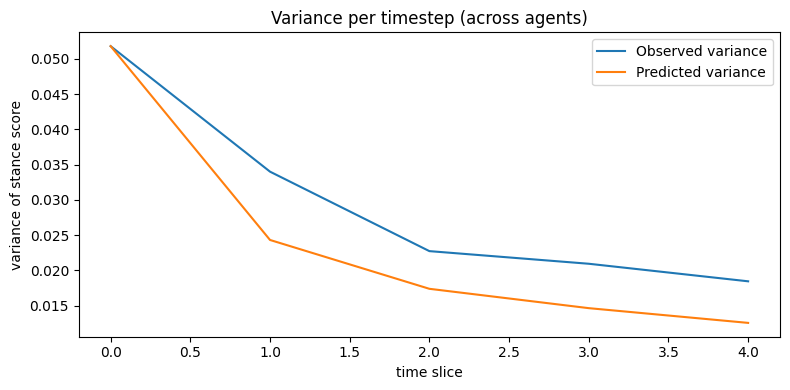

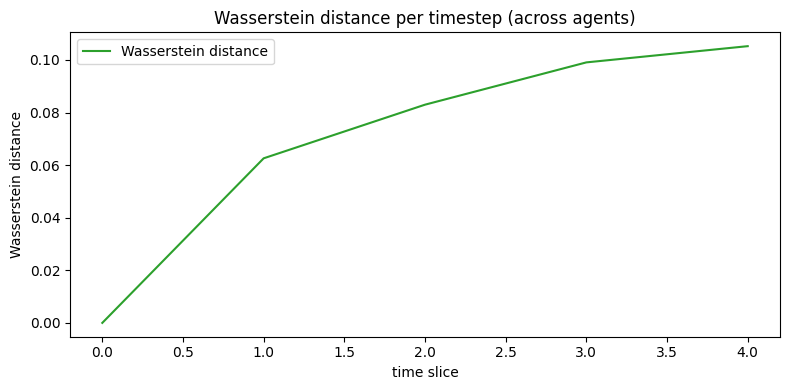

Homophily stubbornness


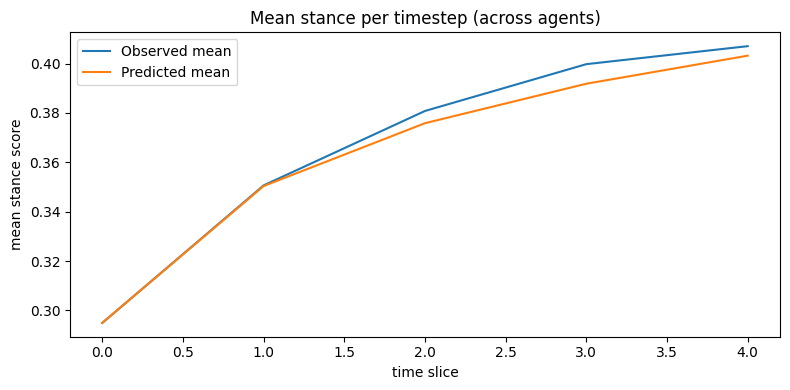

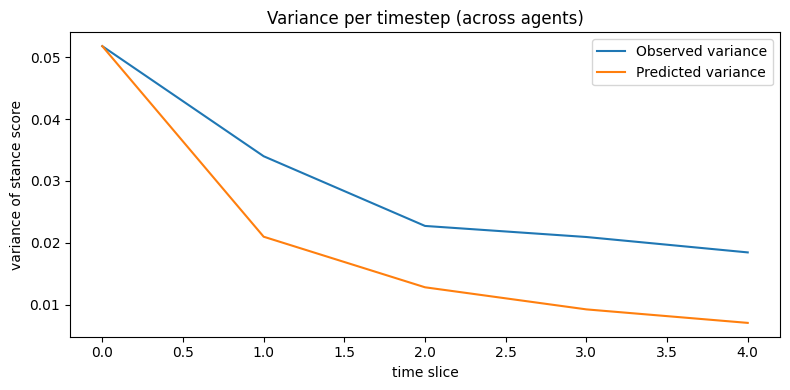

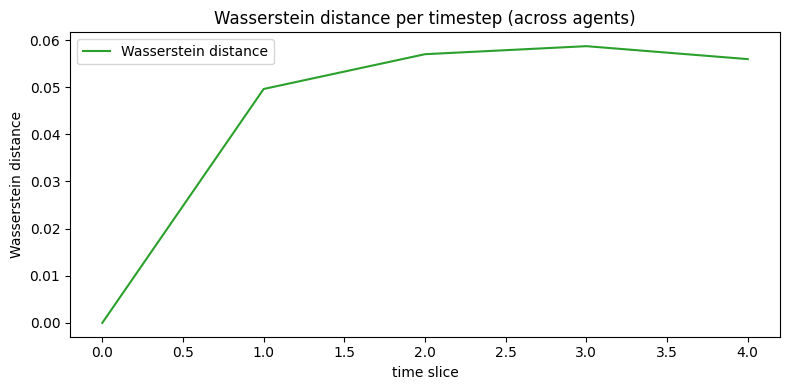

                    model  transition_mse_mean  mean_curve_abs_error  \
0                 degroot             0.027616              0.073101   
1            fj_adjacency             0.015216              0.020733   
2               homophily             0.029411              0.051852   
3  homophily_stubbornness             0.018118              0.024055   

   var_curve_abs_error  wasserstein_curve_mean  
0             0.009176                0.085706  
1             0.010873                0.042206  
2             0.012889                0.069977  
3             0.010461                0.044249  


In [9]:
TEST_DEGROOT = evaluate_validation_model(
    TEST_RUN_TRAJ,
    lambda observed: degroot_rollout_prediction(
        GLOBAL_W,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    ),
)
TEST_FJ_ADJ = evaluate_validation_model(
    TEST_RUN_TRAJ,
    lambda observed: friedkin_johnsen_adjacency_rollout(
        FJ_ADJ_W,
        FJ_ADJ_BIAS,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        FJ_ADJ_L1,
        FJ_ADJ_L2,
    ),
)
TEST_HOMO = evaluate_validation_model(
    TEST_RUN_TRAJ,
    lambda observed: rollout_with_homophily(
        HOMOPHILY_A,
        HOMOPHILY_GAMMA,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    ),
)
TEST_HOMO_STUB = evaluate_validation_model(
    TEST_RUN_TRAJ,
    lambda observed: rollout_with_homophily_stubborness(
        HOMO_STUB_A,
        HOMO_STUB_GAMMA,
        HOMO_STUB_BIAS,
        HOMO_STUB_L1,
        HOMO_STUB_L2,
        np.asarray(observed, dtype=float)[0],
        PARAMS["rollout_horizon_cap"],
    ),
)

VALIDATION_CURVE_HORIZON = min(
    TEST_DEGROOT['mean_true_stack'].shape[1],
    TEST_FJ_ADJ['mean_true_stack'].shape[1],
    TEST_HOMO['mean_true_stack'].shape[1],
    TEST_HOMO_STUB['mean_true_stack'].shape[1],
)

print('Validation metric horizon (shared):', VALIDATION_CURVE_HORIZON)

print('Degroot')
plot_mean_per_timestep(
    TEST_DEGROOT['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_DEGROOT['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_DEGROOT['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_DEGROOT['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_DEGROOT['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

print('FJ adjacency')
plot_mean_per_timestep(
    TEST_FJ_ADJ['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_FJ_ADJ['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_FJ_ADJ['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_FJ_ADJ['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_FJ_ADJ['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

print('Homophily')
plot_mean_per_timestep(
    TEST_HOMO['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_HOMO['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_HOMO['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

print('Homophily stubbornness')
plot_mean_per_timestep(
    TEST_HOMO_STUB['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO_STUB['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_HOMO_STUB['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO_STUB['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_HOMO_STUB['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

test_summary = pd.DataFrame([
    {
        'model': 'degroot',
        'transition_mse_mean': TEST_DEGROOT['transition_mse_mean'],
        'mean_curve_abs_error': TEST_DEGROOT['mean_curve_abs_error'],
        'var_curve_abs_error': TEST_DEGROOT['var_curve_abs_error'],
        'wasserstein_curve_mean': TEST_DEGROOT['wasserstein_curve_mean'],
    },
    {
        'model': 'fj_adjacency',
        'transition_mse_mean': TEST_FJ_ADJ['transition_mse_mean'],
        'mean_curve_abs_error': TEST_FJ_ADJ['mean_curve_abs_error'],
        'var_curve_abs_error': TEST_FJ_ADJ['var_curve_abs_error'],
        'wasserstein_curve_mean': TEST_FJ_ADJ['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily',
        'transition_mse_mean': TEST_HOMO['transition_mse_mean'],
        'mean_curve_abs_error': TEST_HOMO['mean_curve_abs_error'],
        'var_curve_abs_error': TEST_HOMO['var_curve_abs_error'],
        'wasserstein_curve_mean': TEST_HOMO['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily_stubbornness',
        'transition_mse_mean': TEST_HOMO_STUB['transition_mse_mean'],
        'mean_curve_abs_error': TEST_HOMO_STUB['mean_curve_abs_error'],
        'var_curve_abs_error': TEST_HOMO_STUB['var_curve_abs_error'],
        'wasserstein_curve_mean': TEST_HOMO_STUB['wasserstein_curve_mean'],
    },
])
print(test_summary)

In [ ]:
# AIC/BIC ablation table on validation set.
validation_eval_map = {
    'degroot': (TEST_DEGROOT, 0),
    'stubbornness': (TEST_FJ_ADJ, 4),
    'homophily': (TEST_HOMO, 1),
    'homophily_stubbornness': (TEST_HOMO_STUB, 4),
}

validation_ablation_rows = []
for model_name, (eval_result, num_params) in validation_eval_map.items():
    y_true_flat, y_pred_flat = flatten_eval_result(eval_result)
    mean_stats = compute_mean_prediction_error(y_true_flat, y_pred_flat, num_params=num_params)
    max_stats = compute_max_prediction_error(y_true_flat, y_pred_flat, num_params=num_params)
    validation_ablation_rows.append({
        'model': model_name,
        'num_params': num_params,
        'mean_abs_error': mean_stats['mean_error'],
        'max_abs_error': max_stats['max_error'],
        'mse_aic': mean_stats['aic'],
        'mse_bic': mean_stats['bic'],
        'mae_aic': max_stats['aic'],
        'mae_bic': max_stats['bic'],
    })

validation_ablation_aic_bic = pd.DataFrame(validation_ablation_rows).sort_values('mse_aic').reset_index(drop=True)
print(validation_ablation_aic_bic)

                       model  num_params  mean_abs_error  max_abs_error  \
0  stubbornness_fj_adjacency           4        0.080269       0.820657   
1     homophily_stubbornness           4        0.086145       0.867741   
2                    degroot           0        0.118762       0.788476   
3                  homophily           1        0.102891       0.981430   

       mse_aic      mse_bic     mae_aic     mae_bic  
0 -7889.792159 -7867.614830 -739.119389 -716.942061  
1 -7590.039537 -7567.862208 -528.238076 -506.060748  
2 -6819.988920 -6819.988920 -898.329081 -898.329081  
3 -6734.133674 -6728.589342  -68.854929  -63.310596  


Validation sample run: run_20260414-043038
Plot horizon (slices): 9


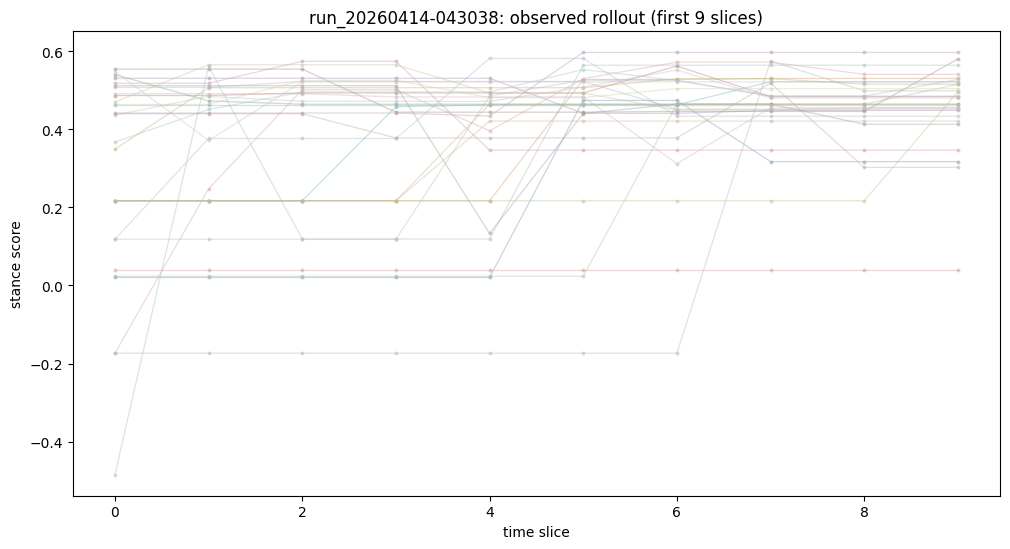

Per-trajectory diagnostics for model: degroot


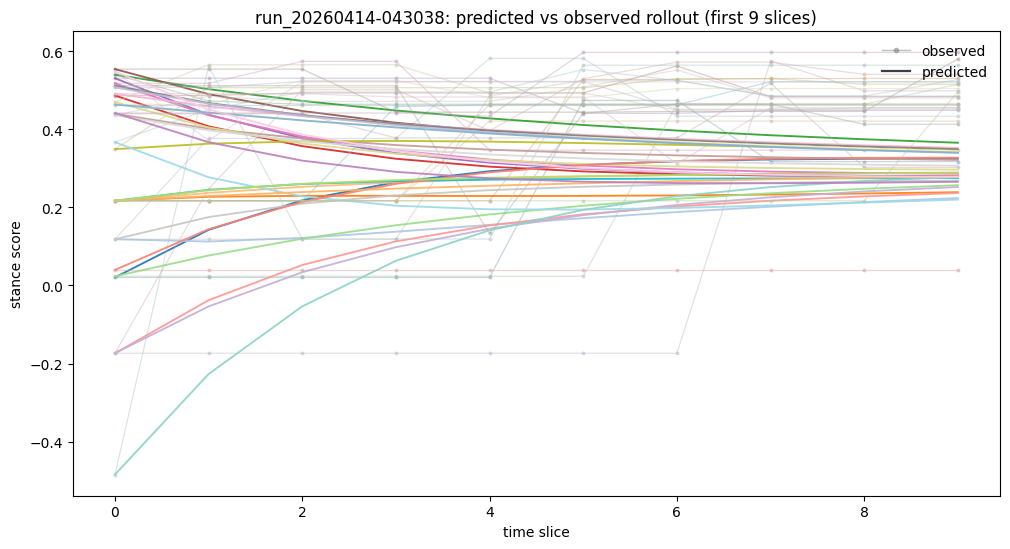

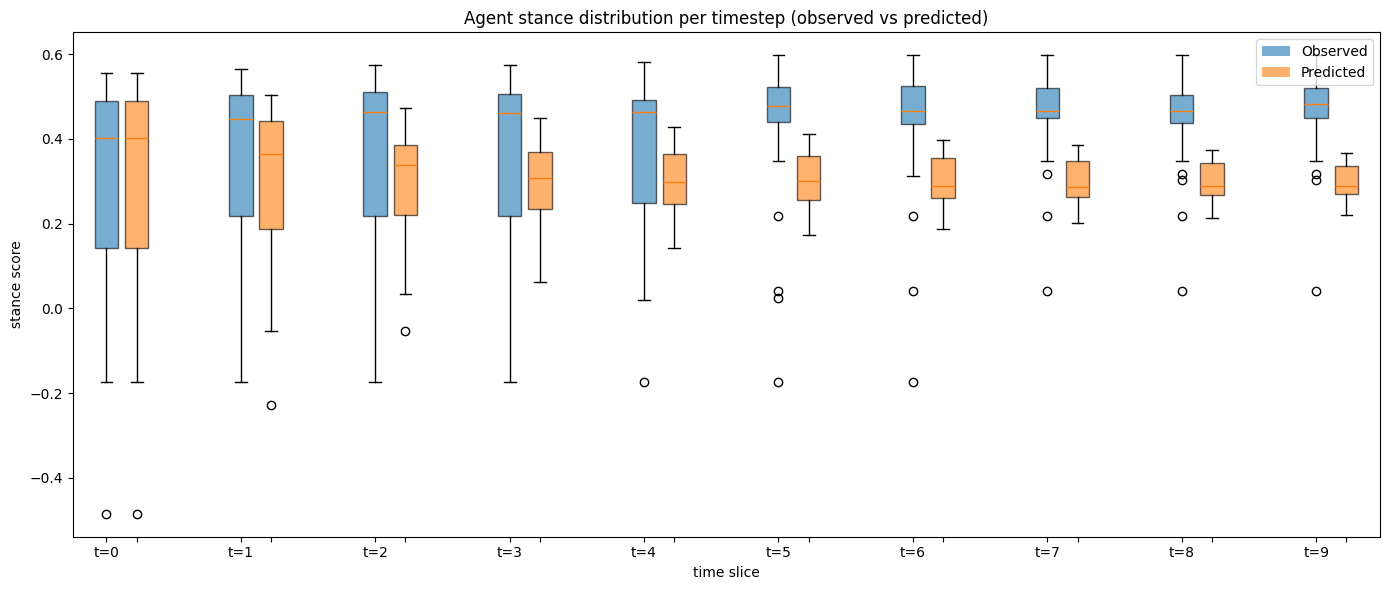

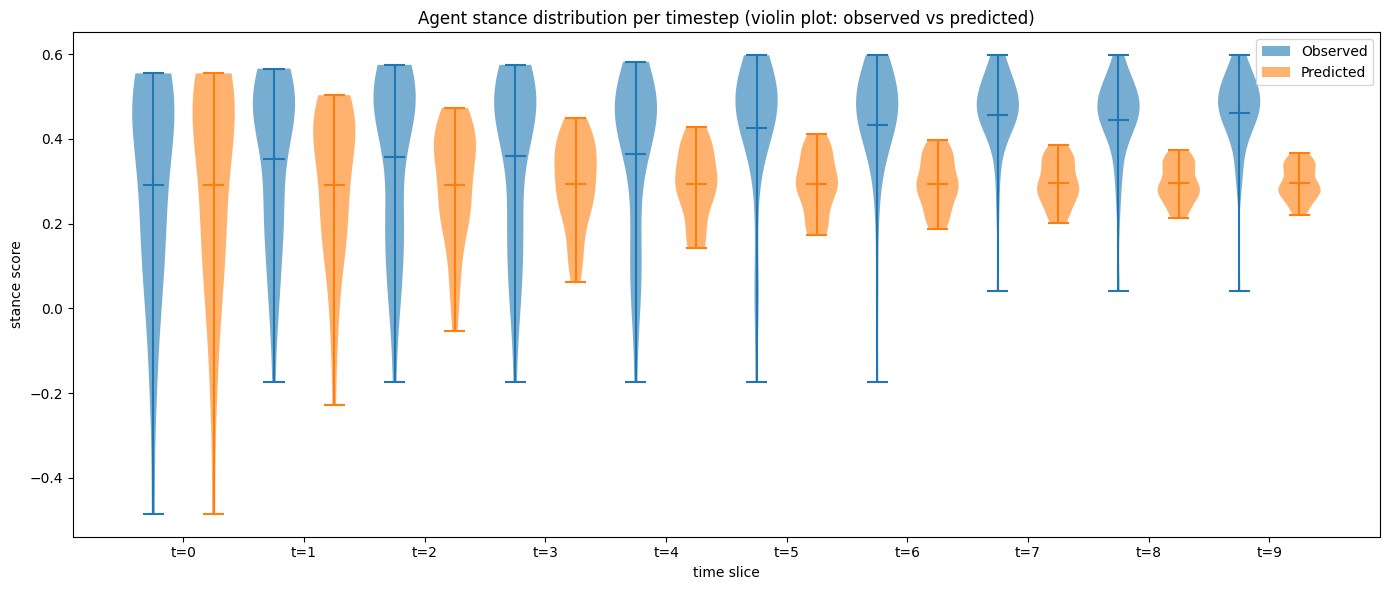

Per-trajectory diagnostics for model: stubbornness_fj_adjacency


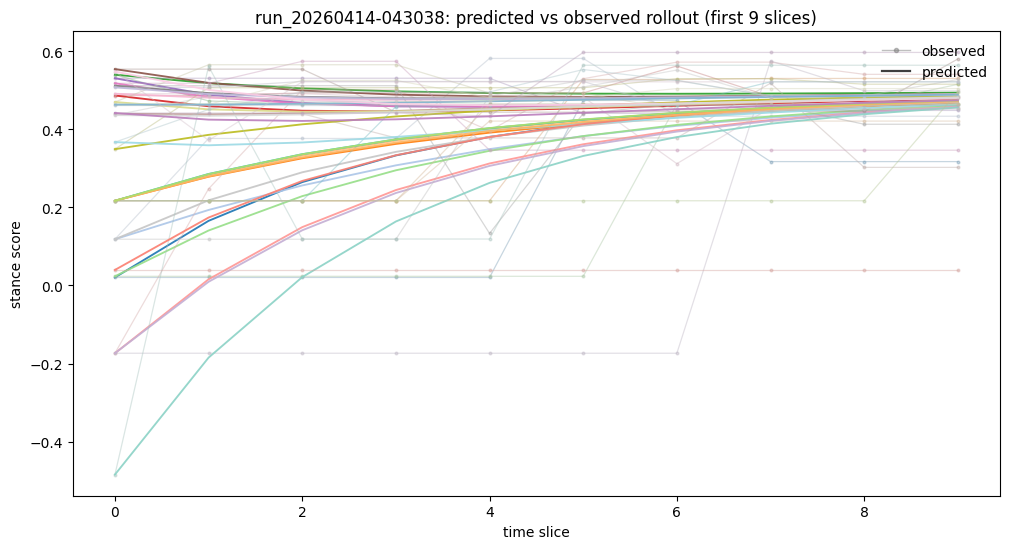

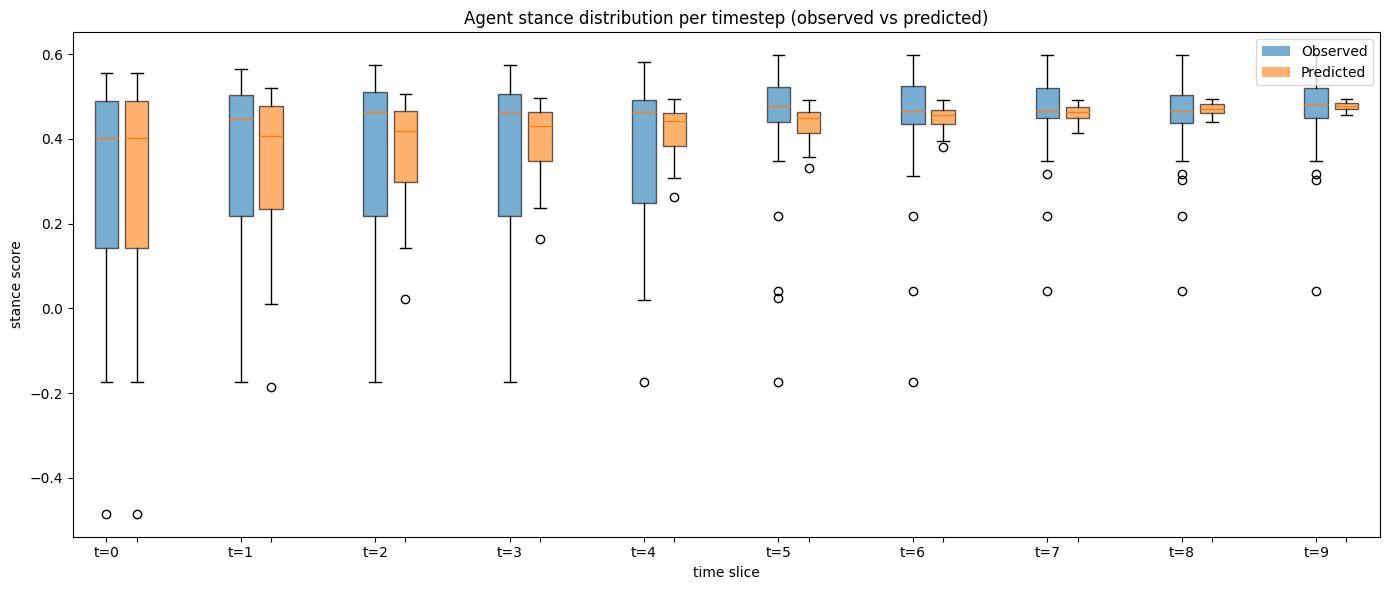

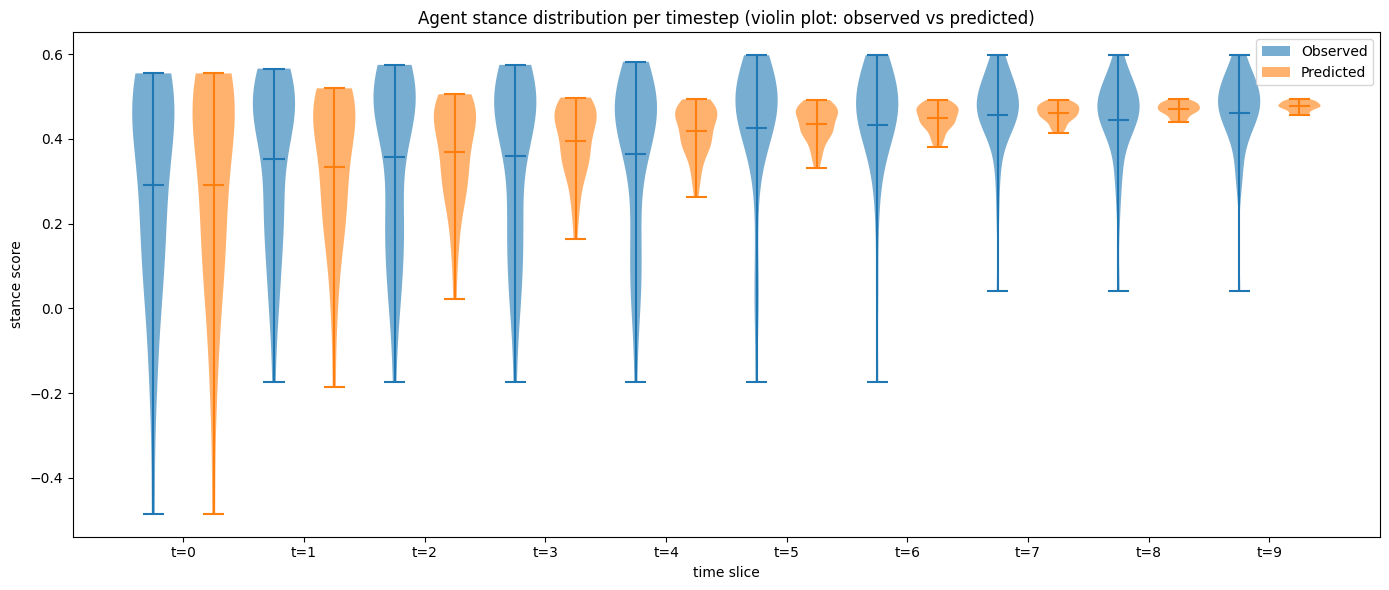

Per-trajectory diagnostics for model: homophily


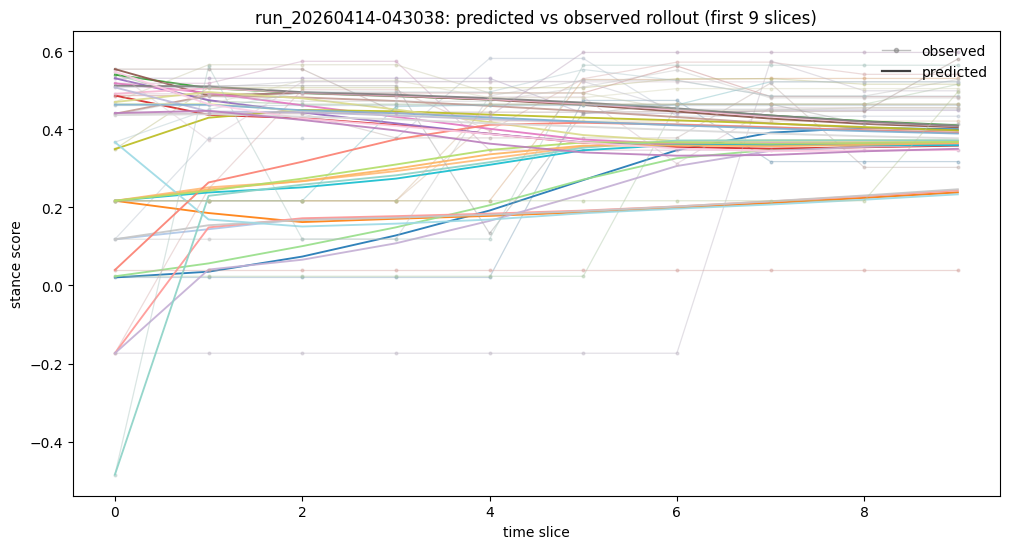

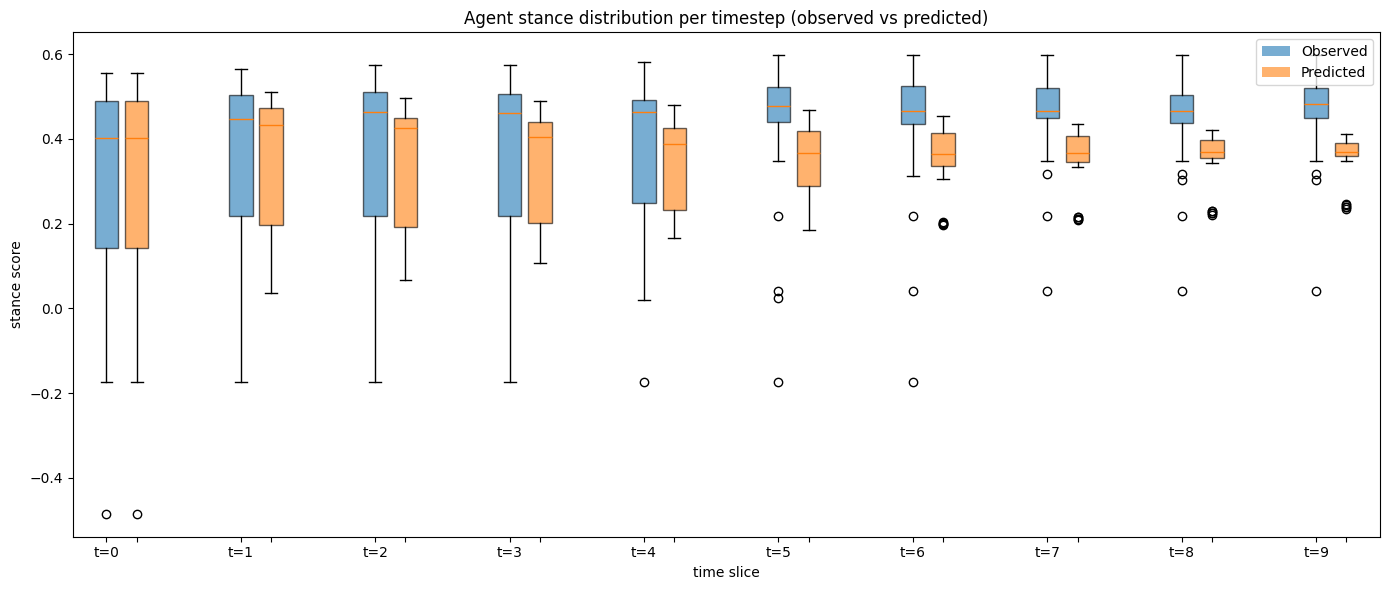

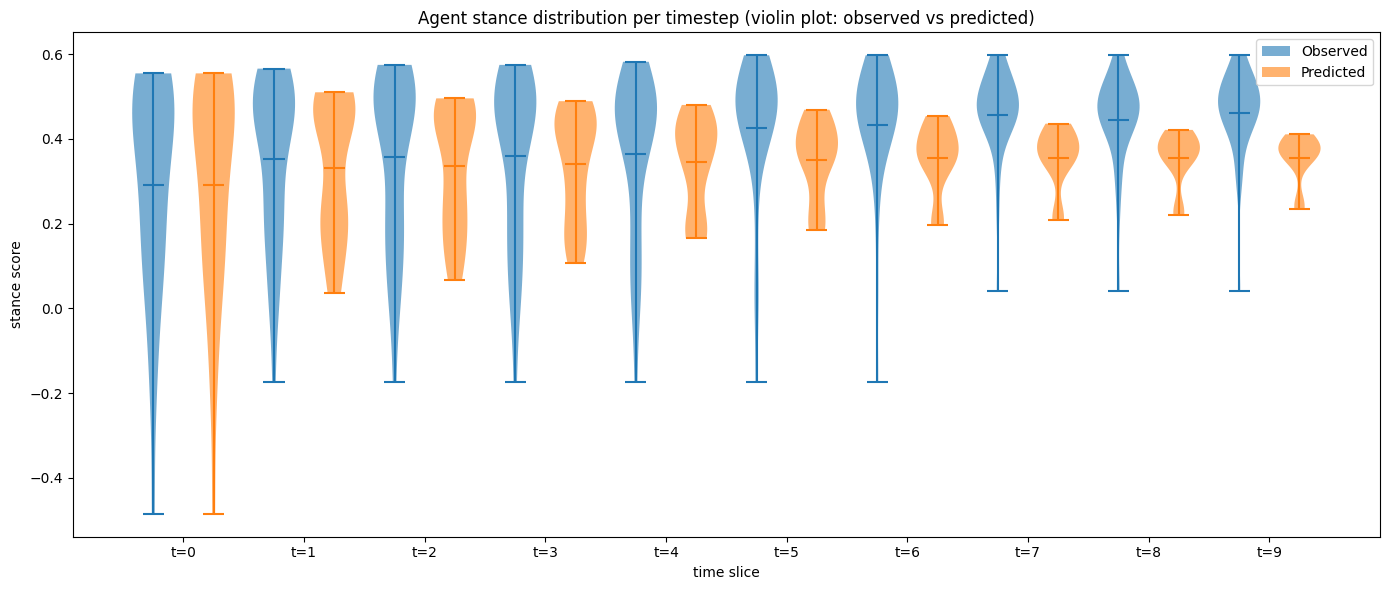

Per-trajectory diagnostics for model: homophily_stubbornness


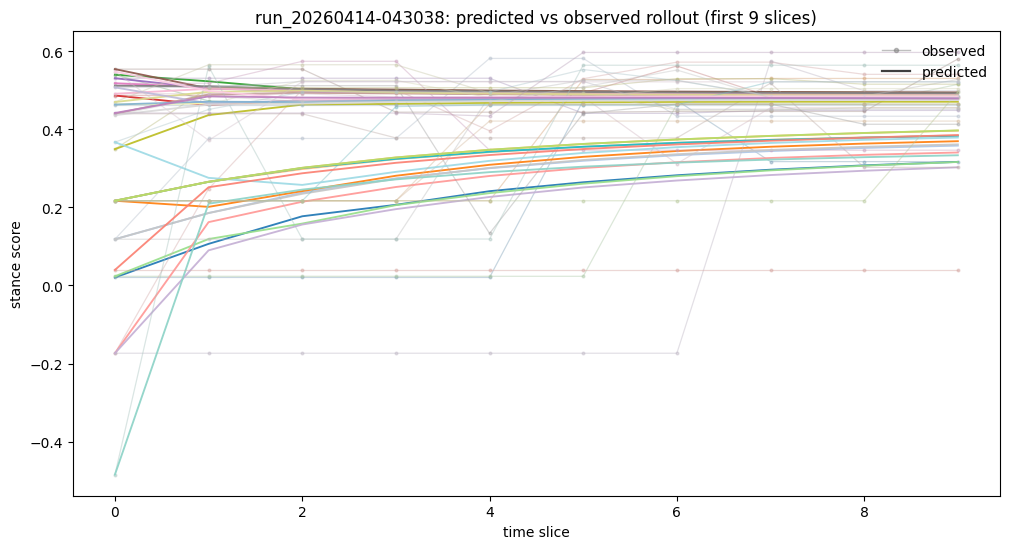

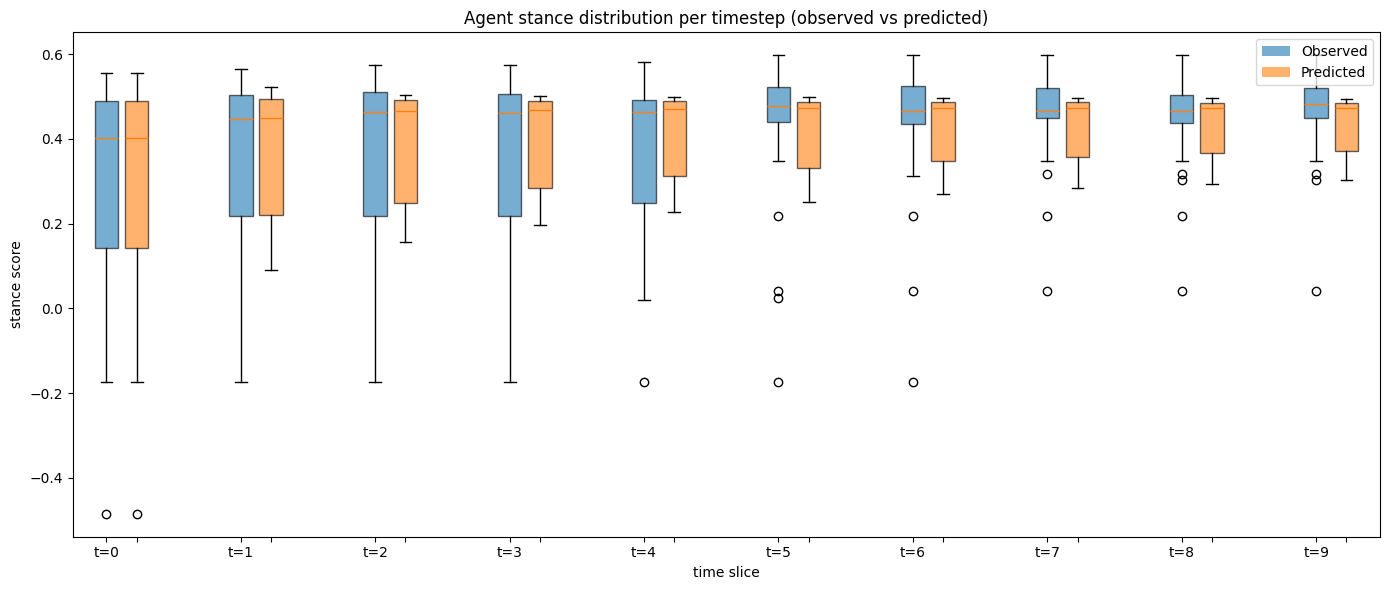

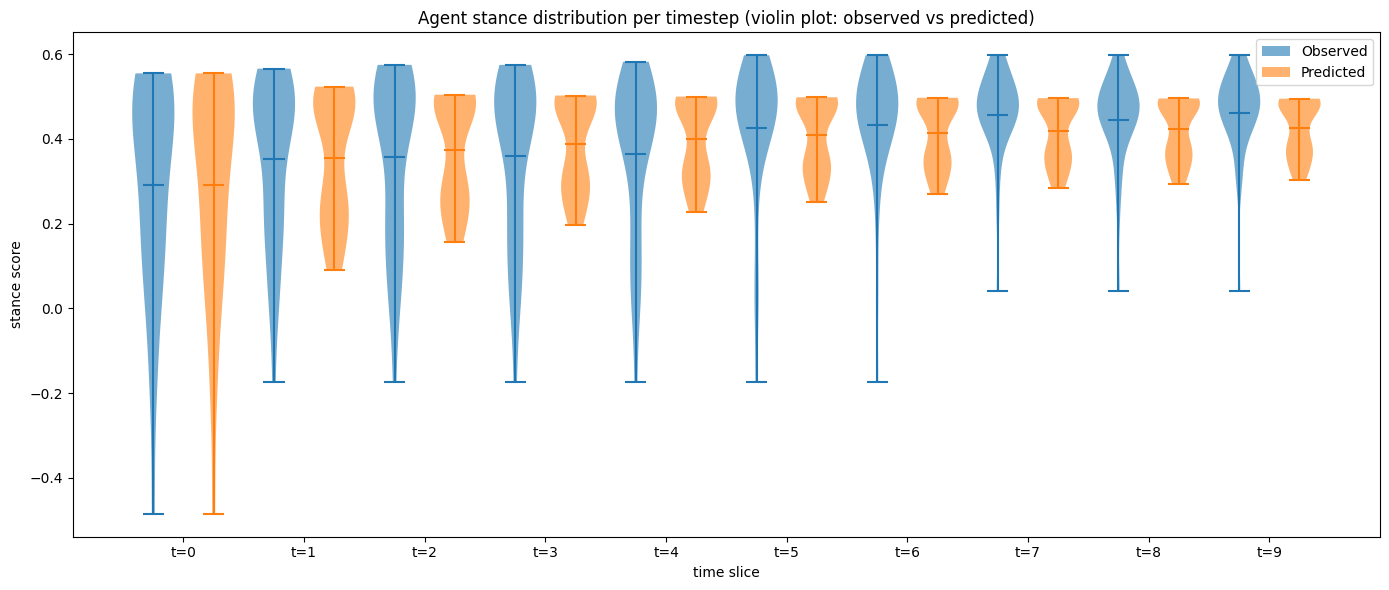

In [11]:
PREDICTED_TEST_HOMO = {
    rn: rollout_with_homophily(HOMOPHILY_A, HOMOPHILY_GAMMA, np.asarray(TEST_RUN_TRAJ[rn], dtype=float)[0], PARAMS['rollout_horizon_cap'])
    for rn in TEST_RUN_TRAJ.keys()
}
PREDICTED_TEST_DEGROOT = {
    rn: degroot_rollout_prediction(GLOBAL_W, np.asarray(TEST_RUN_TRAJ[rn], dtype=float)[0], PARAMS['rollout_horizon_cap'])
    for rn in TEST_RUN_TRAJ.keys()
}
PREDICTED_TEST_FJ_ADJ = {
    rn: friedkin_johnsen_adjacency_rollout(
        FJ_ADJ_W,
        FJ_ADJ_BIAS,
        np.asarray(TEST_RUN_TRAJ[rn], dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        FJ_ADJ_L1,
        FJ_ADJ_L2,
    )
    for rn in TEST_RUN_TRAJ.keys()
}
PREDICTED_TEST_HOMO_STUB = {
    rn: rollout_with_homophily_stubborness(
        HOMO_STUB_A,
        HOMO_STUB_GAMMA,
        HOMO_STUB_BIAS,
        HOMO_STUB_L1,
        HOMO_STUB_L2,
        np.asarray(TEST_RUN_TRAJ[rn], dtype=float)[0],
        PARAMS["rollout_horizon_cap"],
    )
    for rn in TEST_RUN_TRAJ.keys()
}

run_id = max(TEST_RUN_NAMES, key=lambda rn: np.asarray(TEST_RUN_TRAJ[rn], dtype=float).shape[0])
plot_horizon = min(
    10,
    np.asarray(TEST_RUN_TRAJ[run_id], dtype=float).shape[0] - 1,
    np.asarray(PREDICTED_TEST_HOMO[run_id], dtype=float).shape[0] - 1,
    np.asarray(PREDICTED_TEST_DEGROOT[run_id], dtype=float).shape[0] - 1,
    np.asarray(PREDICTED_TEST_FJ_ADJ[run_id], dtype=float).shape[0] - 1,
    np.asarray(PREDICTED_TEST_HOMO_STUB[run_id], dtype=float).shape[0] - 1,
)

print('Validation sample run:', run_id)
print('Plot horizon (slices):', plot_horizon)

plot_observed_trajectories(run_id, TEST_RUN_TRAJ[run_id], GLOBAL_AGENT_IDS, plot_horizon)

per_model_predictions = [
    ('degroot', PREDICTED_TEST_DEGROOT[run_id]),
    ('stubbornness_fj_adjacency', PREDICTED_TEST_FJ_ADJ[run_id]),
    ('homophily', PREDICTED_TEST_HOMO[run_id]),
    ('homophily_stubbornness', PREDICTED_TEST_HOMO_STUB[run_id]),
]

for model_name, predicted_curve in per_model_predictions:
    print(f'Per-trajectory diagnostics for model: {model_name}')
    plot_predicted_vs_observed(
        run_id,
        TEST_RUN_TRAJ[run_id],
        predicted_curve,
        GLOBAL_AGENT_IDS,
        plot_horizon,
    )

    observed_aligned, predicted_aligned = align_rollout_pair(
        np.asarray(TEST_RUN_TRAJ[run_id], dtype=float),
        np.asarray(predicted_curve, dtype=float),
    )
    observed_aligned = observed_aligned[: plot_horizon + 1]
    predicted_aligned = predicted_aligned[: plot_horizon + 1]

    plot_box_per_timestep(observed_aligned, predicted_aligned)
    plot_violin_per_timestep(observed_aligned, predicted_aligned)